This notebook contains some exploration of the NNMF templates for the DESI Dwarf catalog

In [279]:
import numpy as np
import matplotlib.pyplot as plt
# Define normalization
import os
import random
import argparse
from astropy.table import Table, vstack
import h5py
import matplotlib as mpl
import sys

%load_ext autoreload
%autoreload 2

    
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [280]:

import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'tight',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})


MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar



In [281]:
from desi_lowz_funcs import make_subplots

In [12]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# load the MAIN extension directly as an Astropy Table
data_cat = Table.read(filename, hdu="MAIN")


In [13]:
# from astropy.io import fits

# with fits.open(filename) as hdul:
#     h = hdul["MAIN"]
#     i = h.columns.names.index("ZWARN")
#     print("TFORM:", h.columns[i].format)  # "1L" => logical (→ bool in Table)

In [116]:
h5_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/desi_dr1_dwarf_catalog_nnmf_pca_NEW.h5"
with h5py.File(h5_path, "r") as f:
    # pca_coeffs = f["PCA_COEFFS"][:]       # shape (N, 20)
    # nnmf_coeffs = f["NNMF_COEFFS"][:]     # shape (N, 10)
    tgids = f["TARGETID"][:]
    # norm_facs = f["NORM_FACTOR"][:]
    flux_norm = f["FLUX_NORM"][:]
    wave_rest = f["WAVE_REST"][:]
    # nnmf_rnorm = f["NNMF_RNORM"][:]
    

In [14]:
## load the nnmf templates !
nnmf_temps_NEW = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/nnmf_templates/templates_dwarfs_NEW.npy")

print(nnmf_temps_NEW.shape)



(3980, 10)


In [15]:
pca_temps_NEW = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/pca_components_NEW.npy")

print(pca_temps_NEW.shape)


(20, 3980)


In [18]:
# all_norm_resis = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/norm_residuals_dwarfs_v2.npy"  )

In [20]:
# import numpy as np
# import matplotlib.pyplot as plt

# # nnmf_coeffs has shape (465869, 10)
# corr = np.corrcoef(nnmf_coeffs.T)   # (10, 10)

# fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")
# im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
# ax.set_xticks(range(10)); ax.set_yticks(range(10))
# ax.set_xticklabels([f"T{i+1}" for i in range(10)])
# ax.set_yticklabels([f"T{i+1}" for i in range(10)])
# for i in range(10):
#     for j in range(10):
#         ax.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center",
#                 color="black" if abs(corr[i,j]) < 0.6 else "white", fontsize=9)
# plt.colorbar(im, ax=ax, fraction=0.046)
# ax.set_title("NMF activation coefficient correlations")
# plt.show()

# # Report any pairs worth noting
# print("Pairs with |r| > 0.5:")
# for i in range(10):
#     for j in range(i+1, 10):
#         if abs(corr[i, j]) > 0.5:
#             print(f"  T{i+1} & T{j+1}: r = {corr[i,j]:+.3f}")

In [21]:
# from scipy.stats import spearmanr
# corr_sp, _ = spearmanr(nnmf_coeffs)

In [58]:
import seaborn as sns
import colorcet as cc

palette_1 = cc.glasbey_light[:10]  # bright, distinct
palette_2 = cc.glasbey[:10]  # bright, distinct
palette_3 = sns.color_palette("Paired", 10)
palette_4 = sns.color_palette("colorblind", 10)


In [41]:
from desi_lowz_funcs import make_tall_subplots

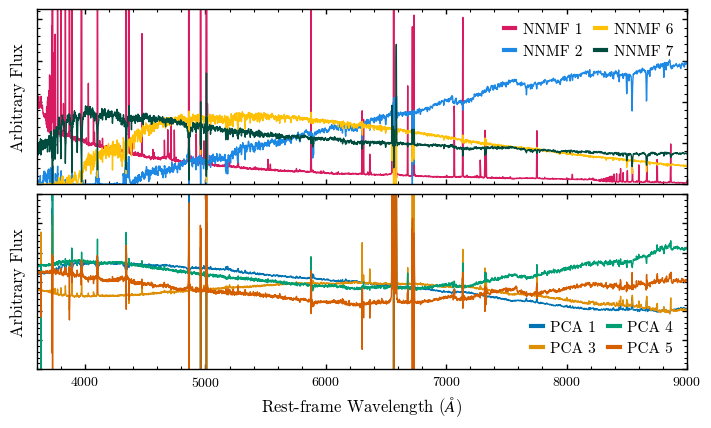

In [115]:
ax = make_tall_subplots(nrow=2, 
                        panel_width=6.5, 
                        panel_height = 1.75,
                        row_spacing=[MARGIN_LABEL, MARGIN_SHARED, MARGIN_PAD]
                       )

for i in range(1,2):
    ax[i].set_xticklabels([])
    ax[0].set_xlabel(r"Rest-frame Wavelength ($\AA$)")


top_inds  = [0, 1, 5, 6]
col_ind = 0

colors = ["#D81B60", "#1E88E5", "#FFC107", "#004D40"]

for i in top_inds:
    ax[1].plot(
        wave_rest,
        nnmf_temps_NEW[:, i],
        color=colors[col_ind],
        label=f"NNMF {i+1}",lw=1
    )
    col_ind += 1


ax[1].set_ylim([0,4.25])

######

bottom_inds = [0,2,3,4]
col_ind = 0

colors = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7"]

for i in bottom_inds:
    ax[0].plot(wave_rest,
            pca_temps_NEW[i],
            color=palette_4[col_ind],
            label=f"PCA {i+1}",lw=1)

    col_ind += 1

ax[0].set_ylim([-0.075,0.075])
locs = ["lower right","upper right"]
for i in range(2):
    ax[i].set_ylabel("Arbitrary Flux")
    ax[i].set_xlim([3600,9000])
    leg = ax[i].legend(frameon=False,ncol=2,handlelength=0.75,handletextpad=0.5, columnspacing=0.8,loc=locs[i])
    ax[i].set_yticklabels([])

    for h in leg.legend_handles:
        h.set_linewidth(3)

plt.savefig("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/plots/nnmf_pca_templates.pdf")

plt.show()

## UMAP analysis: inspect and visualize anomalies

In [118]:
from sfr_and_metallicity import line_snr_mask

In [230]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# load the MAIN extension directly as an Astropy Table
data_cat = Table.read(filename, hdu="MAIN")
spec_temp_cat = Table.read(filename, hdu="SPECTRA_TEMPLATE")
fspec_cat = Table.read(filename, hdu="SPEC_DERIVED")

print(len(data_cat))

keep_mask = spec_temp_cat["SPEC_UMAP_0"] > -50

spec_temp_cat = spec_temp_cat[keep_mask]
data_cat = data_cat[keep_mask]
fspec_cat = fspec_cat[keep_mask]

## let us remove all the objects that do have prominent emission lines!!

line_mask = line_snr_mask(fspec_cat,line_names=["HALPHA","HBETA","OIII_5007","OIII_4959", "OII_3726", "OII_3729","SII_6716"], min_lines=3)

print(np.sum(line_mask)/len(line_mask))

spec_temp_cat = spec_temp_cat[~line_mask]
data_cat = data_cat[~line_mask]
fspec_cat = fspec_cat[~line_mask]

print(len(data_cat))


461543
0.9140076396246487
39689


In [234]:
len(fspec_cat), len(spec_temp_cat)

(39689, 39689)

In [236]:
## get all the targetids in that ball

def inspect_anomalies(spec_cat, umap_x_cen, umap_y_cen, radius_cut = 0.1):
    rads = np.sqrt( (spec_cat["SPEC_UMAP_0"].data - umap_x_cen)**2 + (spec_cat["SPEC_UMAP_1"].data - umap_y_cen)**2 )

    mask = (rads < radius_cut)

    print(f"Objects found = {np.sum(mask)}")
    
    return mask
    

##MASK_1 ARE SOME WEIRD SPECTRA DATA ANOMALIES, like poor sky subtraction etc.
mask_1 = inspect_anomalies(spec_temp_cat, 9,7, radius_cut = 0.5)

#MASK 2 is also unclear, appear like weird spectra or wrong redrock redshifts 
mask_2 = inspect_anomalies(spec_temp_cat, 8.5,8.5, radius_cut = 0.2)

mask_3 = inspect_anomalies(spec_temp_cat,8.125,8.75, radius_cut = 0.1)

mask_4 = inspect_anomalies(spec_temp_cat,6.5,7.5, radius_cut = 0.5)

#the mask 5 contains some incorrect spectra, but mostly correct spectra, we would need some additional work later to find those anomalies
mask_5 = inspect_anomalies(spec_temp_cat,6.2,8.1, radius_cut = 0.1)

mask_6 = inspect_anomalies(spec_temp_cat,3.5,13.5, radius_cut = 0.5)

# 39627821722634552  -> sometimes just a chunk of data is missing in wavelength range

Objects found = 494
Objects found = 25
Objects found = 5
Objects found = 161
Objects found = 147
Objects found = 8


6.55314826965332 7.814903259277344
6.442669868469238 7.588609218597412
6.471313953399658 7.558997631072998
6.303952693939209 7.591858386993408


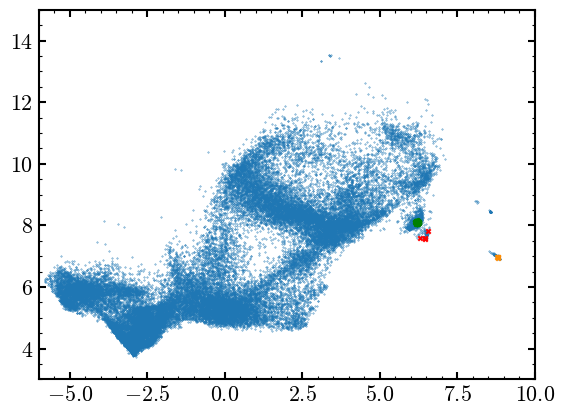

In [240]:
plt.scatter(spec_temp_cat["SPEC_UMAP_0"], spec_temp_cat["SPEC_UMAP_1"], s=0.1)

bad_tgids = [39628023590295406, 39633476617505453, 39627392238491064, 39627462480500683]

for tidi in bad_tgids:
    temp = spec_temp_cat[spec_temp_cat["TARGETID"] == tidi]
    print(temp["SPEC_UMAP_0"][0], temp["SPEC_UMAP_1"][0])
    plt.scatter(temp["SPEC_UMAP_0"][0], temp["SPEC_UMAP_1"][0], s=10,marker="x",color="r")

bad_tgids = [39633447987185055,39636757725057341,39636886834119964,39627984071558664]

for tidi in bad_tgids:
    temp = spec_temp_cat[spec_temp_cat["TARGETID"] == tidi]
    plt.scatter(temp["SPEC_UMAP_0"][0], temp["SPEC_UMAP_1"][0], s=10,marker="x",color="darkorange")
    
plt.xlim([-6,10])
plt.ylim([3,15])

# plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_1], spec_temp_cat["SPEC_UMAP_1"][mask_1], s=2,color="k")
# plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_2], spec_temp_cat["SPEC_UMAP_1"][mask_2], s=2,color="k")
# plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_3], spec_temp_cat["SPEC_UMAP_1"][mask_3], s=2,color="k")
# plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_4], spec_temp_cat["SPEC_UMAP_1"][mask_4], s=2,color="k")
plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_5], spec_temp_cat["SPEC_UMAP_1"][mask_5], s=2,color="green")

# plt.xlim([5.75,7])
# plt.ylim([7,9])
plt.show()

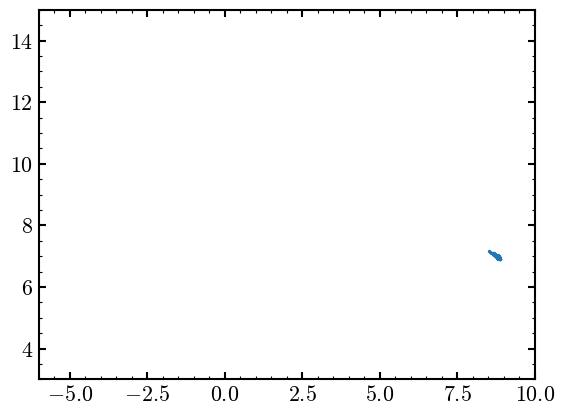

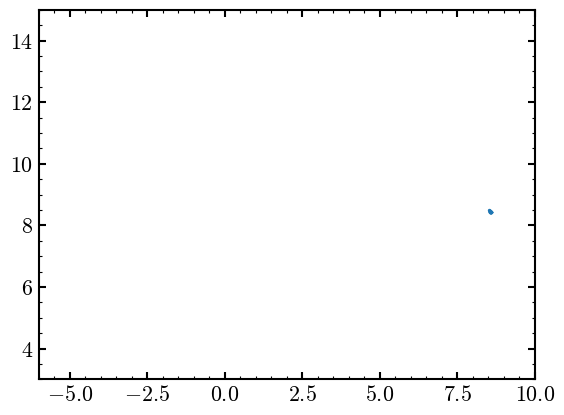

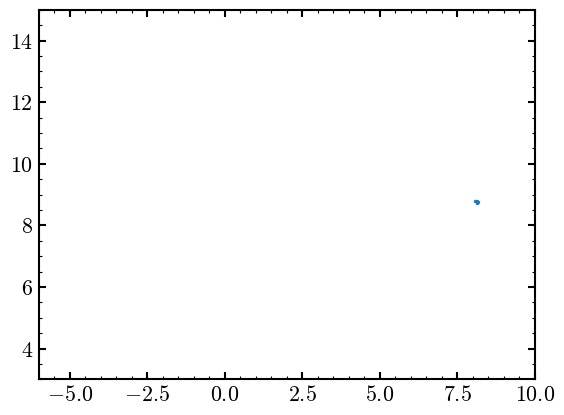

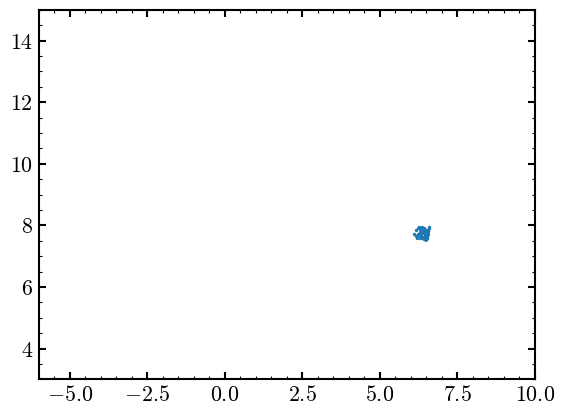

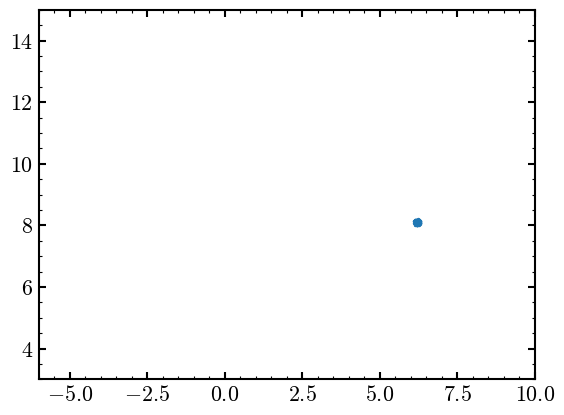

In [238]:
plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_1], spec_temp_cat["SPEC_UMAP_1"][mask_1], s=2)
plt.xlim([-6,10])
plt.ylim([3,15])
plt.show()

plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_2], spec_temp_cat["SPEC_UMAP_1"][mask_2], s=2)
plt.xlim([-6,10])
plt.ylim([3,15])
plt.show()

plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_3], spec_temp_cat["SPEC_UMAP_1"][mask_3], s=2)
plt.xlim([-6,10])
plt.ylim([3,15])
plt.show()

plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_4], spec_temp_cat["SPEC_UMAP_1"][mask_4], s=2)
plt.xlim([-6,10])
plt.ylim([3,15])
plt.show()

plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_5], spec_temp_cat["SPEC_UMAP_1"][mask_5], s=2)
plt.xlim([-6,10])
plt.ylim([3,15])
plt.show()

In [239]:
tgids.shape

(465869,)

In [232]:
flux_norm.shape

(3980, 465869)

In [264]:
mask_1_tgids = spec_temp_cat[mask_1]["TARGETID"].data
mask_2_tgids = spec_temp_cat[mask_2]["TARGETID"].data
mask_3_tgids = spec_temp_cat[mask_3]["TARGETID"].data
mask_4_tgids = spec_temp_cat[mask_4]["TARGETID"].data

mask_1_specmask = np.isin(tgids, mask_1_tgids)
mask_2_specmask = np.isin(tgids, mask_2_tgids)
mask_3_specmask = np.isin(tgids, mask_3_tgids)
mask_4_specmask = np.isin(tgids, mask_4_tgids)


In [265]:
spec_mask_4 =  np.median(flux_norm[:,mask_4_specmask],axis=1)
spec_mask_3 =  np.median(flux_norm[:,mask_3_specmask],axis=1)
spec_mask_2 =  np.median(flux_norm[:,mask_2_specmask],axis=1)
spec_mask_1 =  np.median(flux_norm[:,mask_1_specmask],axis=1)



In [286]:

from desi_lowz_funcs import save_jpg
import requests

save_jpg_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/jpg_imgs"

def get_rgbs(tgids=[39633447987185055,39636757725057341,39636886834119964,39627984071558664],cutout_arcsec=12):
    '''
    Function that returns the RGB elements
    '''

    cutout_size = cutout_arcsec/0.262

    print(int(cutout_size))
    
    session = requests.Session()

    all_paths = []
    all_zreds = []
    all_radec = []
    
    for tgidi in tgids:
        data_cat_i = data_cat[data_cat["TARGETID"] == tgidi]
        ra_i = data_cat_i["RA"][0]
        dec_i = data_cat_i["DEC"][0]
        img_path_i = f"{save_jpg_path}/img_{tgidi}.jpg" 
        save_jpg(ra_i,dec_i,img_path_i,session, size=int(cutout_size) )
        all_paths.append(img_path_i)
        all_zreds.append(data_cat_i["Z"][0])
        all_radec.append(f"({ra_i:.2f},{dec_i:.2f})")

    return all_paths, all_zreds, all_radec, tgids


In [288]:
mask_1_tgids[:5]

array([39627152924085203, 39627335128849091, 39627346164056570,
       39627420659095662, 39627479568090005])

In [289]:
import matplotlib.image as mpimg

paths_mask1, z_mask1, radec_mask1, tgids_mask1 = get_rgbs(tgids=mask_1_tgids[:5],cutout_arcsec=10)



38


In [290]:
paths_mask2, z_mask2, radec_mask2, tgids_mask2 = get_rgbs(tgids=mask_2_tgids[:5],cutout_arcsec=10)
paths_mask4, z_mask4, radec_mask4, tgids_mask4 = get_rgbs(tgids=mask_4_tgids[:5],cutout_arcsec=10)


38
38


In [340]:
tgids_mask1

array([39627152924085203, 39627335128849091, 39627346164056570,
       39627420659095662, 39627479568090005])

In [292]:
rgb_imgs_1 = [mpimg.imread(p) for p in paths_mask1]
rgb_imgs_2 = [mpimg.imread(p) for p in paths_mask2]
rgb_imgs_4 = [mpimg.imread(p) for p in paths_mask4]


In [337]:
all_rgbs = [ rgb_imgs_1, rgb_imgs_2, rgb_imgs_4 ]

In [338]:
all_zs = [z_mask1, z_mask2, z_mask4]

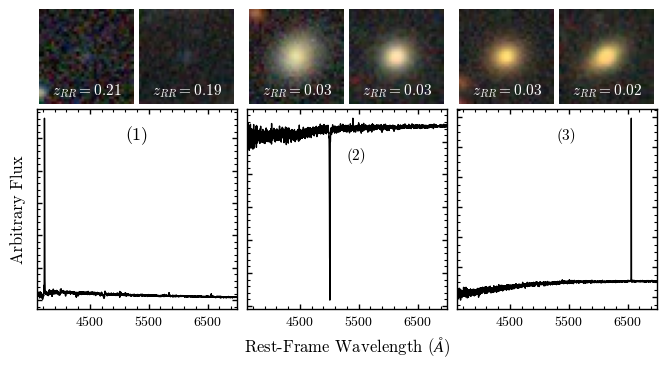

In [358]:

# -----------------------------
# Main figure
# -----------------------------
fig, ax = make_subplots(nrow=1, 
                        ncol=3, 
                        return_fig=True,
                        plot_size=2,    # inches
                        row_spacing = [MARGIN_LABEL, MARGIN_LABEL],
                        col_spacing = [MARGIN_LABEL, MARGIN_SHARED,MARGIN_SHARED, MARGIN_PAD],
                            )

ax[2].plot(wave_rest, spec_mask_4, color="k", lw=1)
ax[1].plot(wave_rest, spec_mask_2, color="k", lw=1)
ax[0].plot(wave_rest, spec_mask_1, color="k", lw=1)


for axi in ax:
    axi.set_xlim([3600, 7000])
    axi.set_yticklabels([])

    ax[1].set_xlabel(r"Rest-Frame Wavelength ($\AA$)")
    axi.set_xticks([4500,5500,6500])

ax[0].set_ylabel("Arbitrary Flux")

fig.canvas.draw()  # forces the divider to resolve all positions


##let us loop over all the axes

for ax_ind in range(3):

    # Get the rightmost panel's bounding box in figure fraction
    bbox = ax[ax_ind].get_position()  # Bbox in figure coords
    
    # Image params
    n_img = 2
    img_height_frac = 0.25  # fraction of figure height — tune this
    img_width_frac  = bbox.width / n_img  # each image gets half the panel width
    
    # Vertically: sit just inside the panel, near the bottom
    img_bottom = bbox.y0 + .539  # small offset from panel bottom edge
    
    # Horizontally: center the block of n_img images over ax[2]
    block_width = img_width_frac * n_img
    img_left = bbox.x0 + (bbox.width - block_width) / 2  # centered
    
    for i in range(n_img):
        ax_img = fig.add_axes([
            img_left + i * img_width_frac,
            img_bottom,
            img_width_frac,
            img_height_frac,
        ])
        ax_img.imshow(all_rgbs[ax_ind][i], origin="lower")
        ax_img.axis("off")
        ax_img.set_aspect("equal")
        ax_img.text(
            0.5, 0.05, r"$z_{RR}=$" f"{all_zs[ax_ind][i]:.2f}",
            transform=ax_img.transAxes,
            ha="center", va="bottom",
            color="white",
        )


ax[0].text(0.5,0.85,r"(1)",color="k",transform=ax[0].transAxes,fontsize = 13,ha="center" )

ax[1].text(0.5,0.75,r"(2)",color="k",transform=ax[1].transAxes )

ax[2].text(0.5,0.85,r"(3)",color="k",transform=ax[2].transAxes )


plt.savefig("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/plots/umap_anomaly_wrong_zrr.pdf")

plt.show()


## Plotting the UMAP plot!!

In [120]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# load the MAIN extension directly as an Astropy Table
data_cat = Table.read(filename, hdu="MAIN")
spec_temp_cat = Table.read(filename, hdu="SPECTRA_TEMPLATE")
fspec_cat = Table.read(filename, hdu="SPEC_DERIVED")

keep_mask = spec_temp_cat["SPEC_UMAP_0"] > -50

spec_temp_cat = spec_temp_cat[keep_mask]
data_cat = data_cat[keep_mask]
fspec_cat = fspec_cat[keep_mask]


In [125]:
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm

def get_edges_counts(spec_cat,mask):
    n_bins = 200
    temp = spec_cat[mask]
    hist, xedges, yedges = np.histogram2d(temp["SPEC_UMAP_0"], temp["SPEC_UMAP_1"], bins=n_bins) 
    # Step 3: Calculate the number of points in each bin
    counts, _, _ = np.histogram2d(temp["SPEC_UMAP_0"], temp["SPEC_UMAP_1"], bins=n_bins)
    return xedges, yedges, counts

elg_mask = (data_cat["SAMPLE"] == "ELG")
no_elg_mask = (data_cat["SAMPLE"] != "ELG")

xedges_elg, yedges_elg, counts_elg = get_edges_counts(spec_temp_cat,elg_mask)
xedges_noelg, yedges_noelg, counts_noelg = get_edges_counts(spec_temp_cat,no_elg_mask)

frac = len(counts_elg)/len(counts_noelg)
counts_elg = counts_elg/frac

counts_elg_m = np.ma.masked_where(counts_elg <= 5, counts_elg)
counts_noelg_m = np.ma.masked_where(counts_noelg <= 1, counts_noelg)

In [204]:
from matplotlib.patches import FancyBboxPatch, Rectangle

def add_dashed_box(ax, x0, y0, width, height, **kwargs):
    """
    Add a dashed rectangle to an axes.
    
    Parameters
    ----------
    ax     : matplotlib axes
    x0, y0 : float — bottom-left corner in data coordinates
    width  : float — box width in data coordinates
    height : float — box height in data coordinates
    **kwargs: passed to Rectangle (override defaults)
    """
    defaults = dict(linewidth=0.6, edgecolor="black", facecolor="none",
                    linestyle="--", zorder=5)
    defaults.update(kwargs)
    ax[0].add_patch(Rectangle((x0, y0), width, height, **defaults))

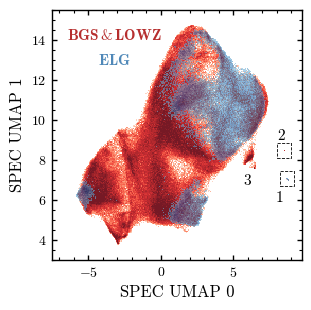

In [223]:

ax = make_subplots(ncol=1,
                   nrow=1,plot_size=2.5)

cmap_elg = plt.cm.Blues.copy()
cmap_elg.set_bad(alpha=0.0)

cmap_noelg = plt.cm.Reds.copy()
cmap_noelg.set_bad(alpha=0.0)

minc=1
maxc=45

ax[0].pcolormesh(xedges_noelg, yedges_noelg, counts_noelg_m.T, shading='auto', 
                 cmap=cmap_noelg,norm=LogNorm(vmin=minc,vmax=maxc),
                 rasterized=True,alpha=0.9)

ax[0].pcolormesh(xedges_elg, yedges_elg, counts_elg_m.T, shading='auto', 
                 cmap=cmap_elg,norm=LogNorm(vmin=minc,vmax=maxc),
                 rasterized=True,alpha=0.55)

ax[0].text(0.25,0.78,r"$\mathbf{ELG}$",transform=ax[0].transAxes,
           color="steelblue",alpha=0.95,weight="bold",ha="center")
ax[0].text(0.25,0.88,r"$\mathbf{BGS\,&\,LOWZ}$",transform=ax[0].transAxes,
           color="firebrick",weight="bold",alpha=0.95,ha="center")

ax[0].set_xlim([-7.5,9.75])
ax[0].set_ylim([3,15.5])

ax[0].set_xlabel(r"SPEC UMAP 0")
ax[0].set_ylabel(r"SPEC UMAP 1")


## denote the islands by some number?

ax[0].text(7.9,5.9,r"$1$",color="k")

ax[0].text(8,9,r"$2$",color="k")

ax[0].text(5.65,6.75,r"$3$",color="k")

#maybe draw a box around the regions?
add_dashed_box(ax, x0=8.2, y0=6.7, width=1, height=0.75)

add_dashed_box(ax, x0=8, y0=8.1, width=1, height=0.75)


plt.savefig("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/plots/umap_spectra_sample.pdf")
plt.show()